In [1]:
import os
import sys
import datetime
import argparse
import pickle
import time
import dataclasses
from dataclasses import dataclass
from itertools import combinations

# Add project root to sys.path
sys.path.append(os.path.dirname(os.getcwd()))

# Set environment variables
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

# JAX config
from jax import config
config.update("jax_enable_x64", True)

# JAX and related imports
import jax
import jax.numpy as jnp
from jax import random, vmap, hessian, jacobian, jit, grad, value_and_grad
from jax.tree_util import Partial, tree_map
from jax_md.quantity import force
# Equinox
import equinox as eqx
import optax
from flax import linen as nn
from flax.training.train_state import TrainState

from jaxopt import LBFGS, GradientDescent
from jaxopt import linear_solve
from jaxopt import OptaxSolver
from jaxopt import tree_util

# Diffrax
import diffrax
from typing import Callable, Optional, Union, Any, Sequence, Literal, List, Tuple, Dict

# tqdm for progress bars
from tqdm.auto import tqdm

# Plotting and matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib as mpl
from cycler import cycler

%matplotlib inline

# Default setting
import matplotlib as mpl
import matplotlib
# import seaborn as sns
from matplotlib import cm
from cycler import cycler

mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# plt.rcParams['text.usetex'] = True # LaTeX
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

# Local project imports
from blockymetamaterials.utils import (
    SolutionType, SolutionData, ControlParams, GeometricalParams, MechanicalParams, LigamentParams, ContactParams
)
from blockymetamaterials.geometry import (
    Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo,
    QuadGeometry_InputSource, polygon_area, polygon_polar_moment
)
from blockymetamaterials.energy import (
    build_strain_energy, kinetic_energy, ligament_energy, ligament_energy_linearized,
    build_contact_energy, combine_block_energies, compute_ligament_strains_history, constrain_energy
)
from cooptimization_real import setup_dynamic_solver, setup_dynamic_solver_all


n1_blocks = 5
n2_blocks = 4
n_source = 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = -25.0*jnp.pi/180
horizontal_shifts, vertical_shifts = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# Mechanical params
k_stretch = 4.00  # stretching stiffness N/mm
k_shear = k_stretch * 2.1e-01 # shearing stiffness  N/mm
k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness Nmm


# Dynamic loading (not used but give it for reference)
amplitude = jnp.ones((n1_blocks,)) * spacing  # 0.5 * spacing default 
loading_rate = 30.0 * jnp.ones((n1_blocks,))# jnp.array([30., 0., 20., 20., 20.])  #  Hz loading frequency for dynamic input
input_shift = 0
loaded_side = "top"
n_excited_blocks = n_source
input_delay = 0.1*30.0**-1 * jnp.ones((n1_blocks,))

min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
bond_length = hinge_length
linearized_strains = True
use_contact = True
k_contact = k_rot * 100.

geometry = QuadGeometry_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_source=n_source
)

target_blocks = geometry.n1_blocks + geometry.n1_blocks//2
print( "target blocks : ", target_blocks )
density = 3.2325226e-08 # 0.03859661 * 1e-6  # Mg/mm^2
density_arr = density * jnp.ones((geometry.n_blocks,))
density_arr = density_arr.at[target_blocks].set( density + 0.007301278265064265 * 1e-6  )

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

k_stretch_arr = k_stretch * jnp.ones((_bond_connectivity.shape[0],))  
k_shear_arr = k_shear * jnp.ones((_bond_connectivity.shape[0],))
k_rot_arr = k_rot * jnp.ones((_bond_connectivity.shape[0],))

dampall = 0.624118 
dampxy = 0.884512
damprot = 0.85392

damping_params = jnp.array([dampall * 0.186, dampxy * 0.36125, damprot * 0.02175026])
print( "initial damping params : ", damping_params )
damping = damping_params[0] * jnp.array([
    2 * (damping_params[1] * density * spacing**2 * k_shear)**0.5,
    2 * (damping_params[1] * density * spacing**2 * k_shear)**0.5,
    2 * (damping_params[2] * density * spacing**4 * k_rot)**0.5
]) * jnp.ones((geometry.n_blocks, 3))

# Damping
print("n blocks : ", geometry.n_blocks)
damped_blocks = jnp.arange(geometry.n_blocks)

driven_block_DOF_pairs = jnp.array([
    jnp.tile(
        jnp.arange( geometry.n_quads,geometry.n_quads+2),
        1),
    jnp.array([1]*n_excited_blocks)
]).T

print("driven_block_DOF_pairs", driven_block_DOF_pairs)

# there are clamped bottom blocks
clamped_block_DOF_pairs_bottom = jnp.array([
    jnp.tile(jnp.arange(geometry.n_quads+2, geometry.n_quads+3), 3),
    jnp.array([0]*1 + [1]*1 + [2]*1)
]).T

constrained_block_DOF_pairs = jnp.concatenate(
    [clamped_block_DOF_pairs_bottom]
)

clamped_blocks_ids = jnp.unique(
    jnp.concatenate([
        clamped_block_DOF_pairs_bottom
    ])[:, 0]
)

driven_blocks_ids = jnp.unique(driven_block_DOF_pairs[:, 0])
print("driven_blocks_ids", driven_blocks_ids)
constrained_DOFs_loading_vector = jnp.zeros((len(constrained_block_DOF_pairs),))

moving_blocks_ids = jnp.arange(geometry.n_blocks-1)
loaded_DOF_ids = jnp.array([block_id * 3 + DOF_id for block_id, DOF_id in driven_block_DOF_pairs])

def pulse(t, amplitude, loading_rate):
    return amplitude * jnp.where(
        (t > 0.) & (t < loading_rate**-1),
        (1 - jnp.cos(2*jnp.pi * loading_rate * t))/2,
        0.
    )
    
excited_blocks_fn = None

if excited_blocks_fn is None:
    # Apply sinthetic pulse loading
    # NOTE: This is used for optimization.
    def constrained_DOFs_fn(t, amplitude, loading_rate, input_delay):
        return 0.0 * constrained_DOFs_loading_vector
else:
    # Apply user-defined loading
    # NOTE: This can be used to apply the experimental loading
    def constrained_DOFs_fn(t, **kwargs):
        return excited_blocks_fn(t) * constrained_DOFs_loading_vector
    
# Construct strain energy
strain_energy = build_strain_energy(
    bond_connectivity=_bond_connectivity,
    bond_energy_fn=ligament_energy_linearized if linearized_strains else ligament_energy,
)
contact_energy = build_contact_energy(bond_connectivity=_bond_connectivity)
potential_energy = combine_block_energies(strain_energy, contact_energy) if use_contact else strain_energy

atol = 1e-4
rtol = 1e-4

free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)
damped_DOF_ids = jnp.concatenate([jnp.arange(block_id * 3, (block_id + 1) * 3) for block_id in damped_blocks])

ts = jnp.linspace(0, simulation_time, n_timepoints)

vertices = centroid_node_vectors(horizontal_shifts, vertical_shifts)
areas = jnp.stack([ polygon_area(vertice) for vertice in vertices ], axis=0) 
area_moments = jnp.stack([ polygon_polar_moment(vertice) for vertice in vertices ], axis=0)
print("areas : ", areas)


# update sensor mass and moment
sensor_mass = 8.58 * 1e-6 # g * 1e-6 for Mg
sensor_moment = 1/12 * (32**2+23**2) * sensor_mass # 
translational_inertia = density_arr * areas
rotational_inertia = density_arr * area_moments
translational_inertia = translational_inertia.at[target_blocks].set( translational_inertia[target_blocks] + sensor_mass )
rotational_inertia = rotational_inertia.at[target_blocks].set( rotational_inertia[target_blocks] + sensor_moment )
_inertia = jnp.column_stack((translational_inertia, translational_inertia, rotational_inertia))
print("inertia : ", _inertia)

@eqx.filter_jit
def forward_problem(inputs, output_data, free_DOF_ids, constrained_DOF_ids, all_DOF_ids):
    
    # Analysis params
    timepoints = jnp.linspace(0.0, simulation_time, n_timepoints)
    horizontal_shifts, vertical_shifts = inputs

    def loading_fn(state, t, **kwargs):
        return vmap(jnp.interp, in_axes=(None,None,1))( t, timepoints, output_data )

    # Setup solver
    # return all DOF ids
    solve_dynamics = setup_dynamic_solver_all(
        geometry=geometry,
        energy_fn=potential_energy,
        free_DOF_ids=free_DOF_ids,
        constrained_DOF_ids=constrained_DOF_ids,
        all_DOF_ids=all_DOF_ids,
        loaded_DOF_ids=loaded_DOF_ids,
        loading_fn=loading_fn,
        constrained_block_DOF_pairs=constrained_block_DOF_pairs,
        constrained_DOFs_fn=constrained_DOFs_fn,
        damped_DOF_ids=damped_DOF_ids,
        atol=atol,
        rtol=rtol,
    )

    # Define control params
    control_params = ControlParams(
        geometrical_params=GeometricalParams(
            block_centroids=block_centroids(horizontal_shifts, vertical_shifts),
            centroid_node_vectors=centroid_node_vectors(horizontal_shifts, vertical_shifts),
        ),
        mechanical_params=MechanicalParams(
            bond_params=LigamentParams(
                k_stretch=k_stretch_arr,
                k_shear=k_shear_arr,
                k_rot=k_rot_arr,
                reference_vector=_reference_bond_vectors,
            ),
            density=density_arr,
            damping=damping,
            contact_params=ContactParams(
                k_contact=k_contact,
                min_angle=min_angle,
                cutoff_angle=cutoff_angle,
            ),
            inertia=_inertia
        ),
        constraint_params=dict(
            amplitude=amplitude,
            loading_rate=loading_rate,
            input_delay=input_delay,
        ),
        loading_params=dict(
            amplitude=amplitude,
            loading_rate=loading_rate,
            input_delay=input_delay,
        ),
    )

    # Initial conditions
    # state0 = jnp.zeros((2, geometry.n_blocks, 3))
    state0 = 1e-10 * jnp.ones((2, geometry.n_blocks, 3))

    start = time.time()
    # Solve dynamics
    solution = solve_dynamics(
        state0=state0,
        timepoints=timepoints,
        control_params=control_params
    )
    print("duration : ", time.time() - start)
    print("solution shape :", solution.shape)
    return solution


target blocks :  7
initial damping params :  [0.11608595 0.31952996 0.01857298]
n blocks :  23
driven_block_DOF_pairs [[20  1]
 [21  1]]
driven_blocks_ids [20 21]
areas :  [136.96231861 136.96231861 136.96231861 136.96231861 136.96231861
 136.96231861 136.96231861 136.96231861 136.96231861 136.96231861
 136.96231861 136.96231861 136.96231861 136.96231861 136.96231861
 136.96231861 136.96231861 136.96231861 136.96231861 136.96231861
 363.61875    363.61875    909.046875  ]
inertia :  [[4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [1.40073379e-05 1.40073379e-05 1.23428513e-03]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 1.01063077e-04]
 [4.42733790e-06 4.42733790e-06 

## Check geometry

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


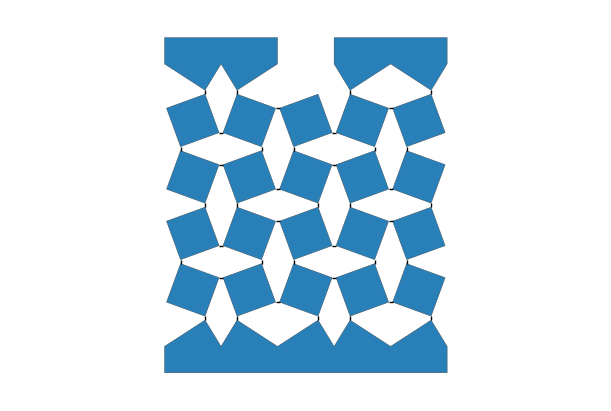

In [2]:
from blockymetamaterials.plotting import generate_animation, generate_frames, plot_geometry, generate_patch_collection

design_values = (horizontal_shifts, vertical_shifts)

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(
        *design_values),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim,
    ylim=ylim,
    figsize=(6, 6*16/24),
)
ax.axis("off")
# plt.savefig('../data/distinguish_two_inputs/initial_design.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Setup force functions

amplitude [-0.3225 -0.3225]


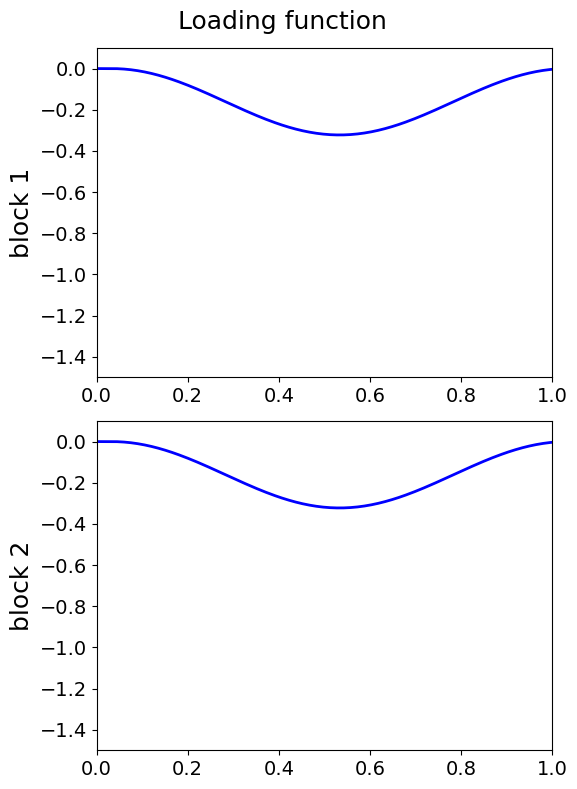

In [5]:
# Dynamic loading (default setting)

def pulse(t, amplitude, loading_rate):
    return amplitude * jnp.where(
        (t > 0.) & (t < loading_rate**-1),
        (1 - jnp.cos(2*jnp.pi * loading_rate * t))/2,
        0.
    )


amplitude = -0.02 * spacing * jnp.ones((n_excited_blocks,))
print("amplitude", amplitude)

loading_rate = 1. * jnp.ones((n_excited_blocks,))  #  Hz loading frequency for dynamic input
input_delay = 0.1*3.0**-1 * jnp.ones((n_excited_blocks,))

ts = jnp.linspace(0, simulation_time, n_timepoints)
def loading_fn(state, t, amplitude, loading_rate, input_delay):
    time_array = t-input_delay
    loading_vector = vmap(pulse, in_axes=(0,0,0))(time_array, amplitude, loading_rate)
    return loading_vector

temp_func = lambda t: loading_fn(None, t, amplitude, loading_rate, input_delay)
loading = vmap(temp_func)(ts)

plt.figure(figsize=(6,8))
for i in range(n_excited_blocks):
    plt.subplot(n_excited_blocks,1,i+1)
    plt.plot(ts, loading[:,i])
    plt.ylabel("block "+str(i+1))
    plt.ylim(-1.5, 0.1)
plt.suptitle("Loading function")
plt.tight_layout() 
plt.show()

duration :  1.5290253162384033
solution shape : (200, 3, 23, 3)


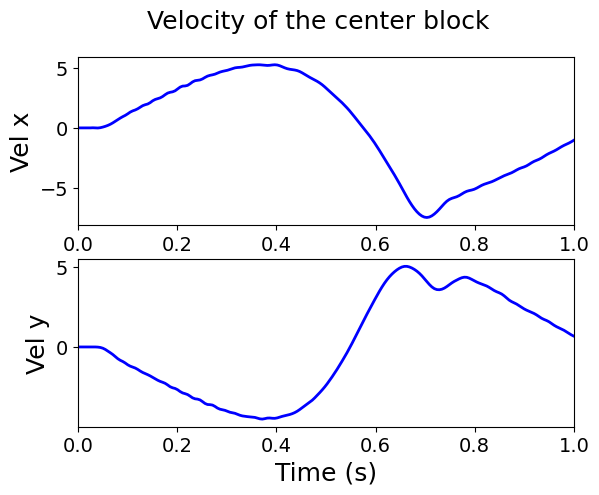

In [6]:
# Design parameters
inputs = (horizontal_shifts, vertical_shifts)

# Run forward problem
start_time = time.time()
solution = forward_problem(inputs, loading, free_DOF_ids, constrained_DOF_ids, all_DOF_ids)
center_idx = geometry.n_quads // 2
measure_data = solution[:,1,center_idx,0:2]
label_list = ["Vel x", "Vel y"]

for i in range(2):
    plt.subplot(2,1,i+1)
    plt.plot(ts, measure_data[:,i])
    plt.ylabel(label_list[i])
    plt.xlabel("Time (s)")
    # plt.ylim([-1000,1000])
plt.suptitle("Velocity of the center block")
plt.show()

In [ ]:
# export animations
solutionData = SolutionData(
    block_centroids=bc_fn(h_shifts, v_shifts),
    centroid_node_vectors=cnv_fn(h_shifts, v_shifts),
    bond_connectivity=_bond_connectivity,
    timepoints=np.array(ts),
    fields=np.array(solution),   # (n_timepoints, 3, n_blocks, 3)
)

        
xlim, ylim = geometry.get_xy_limits(h_shifts, v_shifts) + 0.5 * geometry.spacing * jnp.array([-1, 1])

generate_animation(
    data=solutionData,
    field="theta_abs",
    cmap="turbo",
    out_filename=out_filename,
    deformed=True,
    sync="time",
    fps=30, # 10 seconds
    playback_speed=5.0,
    dpi=300,
    figsize=(6, 6),
    xlim=xlim,
    ylim=ylim,
    grid=False,
    axis=False,
    annotate_time=True,
)
print(f"  Saved: {out_filename}.mp4")
